In [2]:
import pandas as pd
import os

In [ ]:
# This process code is kept when one runs this step from scratch
'''
df_chinese = pd.DataFrame()
for f in os.listdir("dataset/Chinese"):
    print(f)
    if "csv" in f:
        df = pd.read_csv("dataset/Chinese/" +f)
        company, model, language =  f.split("_")[:3]
        prompt =  f.split("_")[-1][:-3]
        temperature =  f.split("_")[-1][-3:]
        df["company"] = company
        df["model"] = model
        df["prompt"] = prompt
        df["temperature"] = temperature
        df_chinese = pd.concat([df_chinese, df])
df_chinese[["book", "book_idx", "source", "UCPs", "response", "model", "prompt"]].to_csv("dataset/intermediate/collected_trans_Chinese.csv", index=False)
'''

In [3]:
df = pd.read_csv("task2_bench/collected_trans_Chinese.csv")
df_example = pd.read_csv("dataset/task2_benchmark_fewshot.csv", sep = ";")
df_example = df_example[["book", "book_idx", "UCPs", "example_zh"]]
df_example.rename(columns = {"UCPs":"UCPs_latest"}, inplace = True) 
df = df.merge(df_example, on = ["book", "book_idx"], how = "left")
df.rename(columns = {"response": "translation"}, inplace = True) 

In [4]:
from string import Template

# classifier
prompt_eval = Template('''
You are an expert in literary translation studies.

Your task is to classify how a specific HIGHLIGHTED segment in a literary SOURCE text
has been translated into the TARGET language. You must focus ONLY on:

- the highlighted source span
- its corresponding translated span extracted from the target translation 

Ignore the rest of the sentence except when it is strictly necessary for context.

--------------------------------
OUTPUT LABELS (YOU MUST PRODUCE ALL FOUR)
--------------------------------

1. Label1: Translation Technique (choose exactly ONE)
   - Creative Shift (CS): translations that deviates from a literal rendering of the source text to create a more impactful, natural, or culturally appropriate translation in the target language in a meaningful or stylistically motivated way. Please make sure the deviation of meaning or image is rooted in the source. If the source meaning is not reflected or much off, this choice should not be labeled as a creative shift but unacceptable (not applicable). Please check the inner logic of the text, if the logic is wrong, then such translation is not acceptable. 
   - Reproduction: The translation conveys the same idea or image as the highlighted source. May still vary in style or acceptability, but the meaning is preserved. 
   - Omission
   - Not acceptable (Error): The translation contains grammar errors of various types or is overly literal. E.g., literally translating "raining cats and dogs" to its mere semantic equivalent “dropping dogs and cats” rather than "heavy rain." 
   - Not acceptable (Not Applicable): If the translation cannot be evaluated as a valid solution (e.g., distorts meaning beyond recognition but does not contain grammar issues, “too creative”; not acceptable to the target audience at all), mark it as Not Applicable (NA). E.g., Raining cats and dogs → A storm of fur filling the heavens. 
   - Uncertain

2. Level_of_creativity ∈ [low, medium, high]: How surprising, inventive, or non-routine the translation choice feels within the given literary context. 
- low    → routine, literal, unsurprising
- medium → some interpretive or stylistic choice
- high   → clearly inventive, or unexpected 

3. Level_of_acceptability ∈ [low, medium, high]:  Overall translation quality and appropriateness in context:
     - low    → clearly unacceptable as a translation
     - medium → understandable but flawed, awkward, or unstable
     - high   → logical, fluent, appropriate, and acceptable for literary use based on the source text. Make sure the word choice is conventional for the audience and make sure it adheres to the source meaning without added information that is not reflected or necessary in the source text. Explain the reasoning why the acceptability is high. 

4. Level of deviation ∈ [low, medium, high]:   
- low    → meaning & imagery preserved
- medium → meaning & imagery partially preserved 
- high   → strongly reimagined meaning or image, with added information

!! Please double-check to ensure the deviation adheres to the source context. Be cautious in cases of medium or high deviation, as this usually indicates changes that go beyond the source meaning and are sometimes unacceptable according to the source context and label definition. Be very cautious with added meanings that are not necessary! If the deviation is labeled medium or high, explain exclusively why this choice is acceptable. 

!! If a translation is labeled as a creative shift, verify that it does not introduce excessive added meaning that cannot be inferred from the source or supported by the context. If it does, the translation is “too creative” and should be marked as unacceptable (not applicable). Likewise, if the translation is illogical or does not make sense in the source context, it is also not acceptable.

[source]:
$source

[highlighted source spans]:
$ucp

--------------------------------
Example evaluation result: 
--------------------------------
$example

--------------------------------
Translation to be analysed
--------------------------------

[translation]:
$translation

--------------------------------
OUTPUT FORMAT (STRICT)
--------------------------------
Return your answer in the following JSON-like format ONLY:
[
  {
    "highlighted_source": "<highlighted span1>",
    "translated_span": "<translated span1>",
    "label": "<Label>",
    "creativity_level": "<Level_of_creativity>",
    "acceptability_level": "<Level_of_acceptability>",
    "deviation_level": "<Level_of_deviation>",
    "reasoning": "<reasoning>"
  }, 
  {
    "highlighted_source": "<highlighted span2>",
    "translated_span": "<translated span2>",
    "label": "<Label>",
    "creativity_level": "<Level_of_creativity>",
    "acceptability_level": "<Level_of_acceptability>",
    "deviation_level": "<Level_of_deviation>",
    "reasoning": "<reasoning>"
  }
]
''')

In [5]:
for idx, row in df.iterrows():
    x = row
    df.loc[idx, "prompt_chinese"] = prompt_eval.substitute(source = x["source"], ucp = x["UCPs_latest"], translation = x["translation"], example = x["example_zh"])

In [6]:
df.to_csv("dataset/intermediate/Chinese_prompt4_eval.csv", index = False) 

In [59]:
# task 2 evaluator.py to run the evaluation code
# !python task2_evaluator.py 

In [9]:
# parse collected data 
def fix_json_string(json_str):
    json_str = json_str.replace("```json", "").replace("```", "").replace("\n[", "[").replace("]\n", "]").replace("*", "")
    json_str = json_str.replace('\\n', '\n').replace('\\t', '\t')
    # 1. If the string is enclosed in single quotes, remove them
    if json_str.startswith("'") and json_str.endswith("'"):
        json_str = json_str[1:-1]
    
    # 2. Replace em dashes with double hyphens
    json_str = json_str.replace('—', '--')
    
    # 3. Handle escape sequences and newlines within strings
    result = []
    i = 0
    in_string = False
    escape_next = False
    string_start = 0
    
    while i < len(json_str):
        char = json_str[i]
        
        # Toggle string state when we encounter an unescaped quote
        if char == '"' and not escape_next:
            if not in_string:
                # Beginning of a string
                in_string = True
                string_start = i
            else:
                # End of a string - process the entire string content
                string_content = json_str[string_start+1:i]
                
                # Replace literal newlines with \n
                string_content = string_content.replace('\n', '\\n').replace('\r', '\\r')
                
                # Ensure single quotes are properly escaped
                string_content = string_content.replace("\\'", "'").replace("'", "\\'")
                
                # Add the processed string with its quotes
                result.append('"' + string_content + '"')
                in_string = False
                string_start = 0
        elif not in_string:
            # Outside of strings, add character as-is
            result.append(char)
        # Inside strings, characters are handled when the string ends
        
        # Update escape flag
        escape_next = char == '\\' and not escape_next
        i += 1
    
    return ''.join(result)


In [10]:
eval_df = pd.DataFrame()
for f in os.listdir("dataset//result/"):
    if "qwen" in f:
        try:
            eval_ = pd.read_csv("dataset/result/" + f, sep = ";")
        except:
            eval_ = pd.read_csv("dataset/result/" + f)
        eval_model = f.split("_")[1]
        eval_["eval_model"] = eval_model
        eval_df = pd.concat([eval_df, eval_])
        print("Eval dataset loaded: ", f)
print(eval_df.shape)
eval_df = eval_df.dropna().reset_index()
print(eval_df.shape)

Eval dataset loaded:  qwen_qwen3-next-80b-a3b-thinking_chinese0_removingPERSONALDATA_verion.csv
(1012, 13)
(1000, 14)


In [11]:
import ast
res = pd.DataFrame()
for idx, row in eval_df.dropna().iterrows():
    import json 
    if ("[" in row["response"]) & (row.isna().sum() ==0):
        response = row["response"].replace('[1]', "")
        try:
            fixed_json = fix_json_string(response[response.index("JSON:\n\n") + 1:])
        except:
            fixed_json = fix_json_string(response[response.index("[\n  {"):])
        df = pd.DataFrame(ast.literal_eval(fixed_json.replace("SON:\n", "")))
        df["eval_model"] = row["eval_model"]
        df["book"] = row["book"]
        df["book_idx"] = row["book_idx"]
        df["translation_model"] = row["model"]
        df["prompt_mode"] = row["prompt"]
        df["translation"] = row["translation"]
        res = pd.concat([res, df])

In [14]:
res.highlighted_source.replace({'Murray’s Grammar,[1]': 'Murray’s Grammar'}, inplace = True)
res.label.replace({'Creative Shift (CS)': 'Creative Shift'}, inplace = True)
res.label.unique()
res.shape

(7631, 13)

In [15]:
order = ["low", "medium", "high"]

res["creativity_level"] = pd.Categorical(
    res["creativity_level"],
    categories=order,
    ordered=True
)
res["acceptability_level"] = pd.Categorical(
    res["acceptability_level"],
    categories=order,
    ordered=True
)


def score_map(row, weight):
    acc_l = row["acceptability_level"]
    crea_l = row["creativity_level"]
    if row["label"] == "Creative Shift":
        score = weight[acc_l] #1*weight[crea_l]*
    elif "acceptable" in row["label"]:
        score=-1
    else:
        score=0
    return score

weight = {"low":1, "medium": 1, "high": 1}
res["score_orig"] = res.apply(lambda x: score_map(x, weight), axis =1)

In [16]:
d1 = res.groupby(["eval_model",  "translation_model", "book", "prompt_mode"], as_index = False).score_orig.mean()
d1["max_v"] = d1.groupby(["eval_model",  "translation_model", "book"]).score_orig.transform("max")

In [ ]:
#reg comprenhension score, model size, prompt mode, 
df8 = pd.read_csv("../task1_comprehension//result/task1_analysis_sub8.csv")
df = pd.read_csv("../task1_comprehension//result/task1_comparison.csv")
df8 = pd.merge(df8, df[['model', 'size', "Reasoning", "MOE"]], on = "model", how = "left") # merge for size

In [19]:

d1 = res.groupby(["eval_model", "translation_model", "prompt_mode",], as_index = False)[["score_orig"]].mean()#.to_csv("eval_result.csv", index = False)
d1["max_v"] = d1.groupby(["translation_model"]).score_orig.transform(max)

d1["prompt_mode"] = d1["prompt_mode"].astype("category")
d1["if_max"] = d1["max_v"] == d1["score_orig"]
# optional: control the order shown on the x-axis
order = ["base", "p1", "p2", "p3"]  # change to yours
d1["prompt_mode"] = d1["prompt_mode"].cat.reorder_categories(order, ordered=True)

reg = pd.merge(df8, d1, left_on = "model", right_on = "translation_model", how = "right")


/var/folders/2n/4742tn7s13l5fcnstlm_d7g40000gn/T/ipykernel_71705/1409425183.py:2: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  d1["max_v"] = d1.groupby(["translation_model"]).score_orig.transform(max)


In [21]:
pd.DataFrame(reg.groupby(["translation_model"]).score_orig.mean())

,score_orig
translation_model,
claude-3.7-sonnet,-0.110119
claude-3.7-sonnet:thinking,-0.061418
deepseek-r1-0528,0.038690
deepseek-v3.2-exp,0.017857
gemini-2.5-flash-lite,-0.139881
gemini-2.5-flash-preview-09-2025,-0.041667
gpt-4o-2024-11-20,-0.064331
gpt-4o-mini-2024-07-18,-0.196429
gpt-5.1,-0.090077


In [14]:
pd.DataFrame(reg.groupby(["translation_model"]).score_orig.max())

,score_orig
translation_model,
claude-3.7-sonnet,-0.071429
claude-3.7-sonnet:thinking,0.011905
deepseek-r1-0528,0.071429
deepseek-v3.2-exp,0.059524
gemini-2.5-flash-lite,-0.095238
gemini-2.5-flash-preview-09-2025,0.023810
gpt-4o-2024-11-20,-0.013514
gpt-4o-mini-2024-07-18,-0.166667
gpt-5.1,-0.083333


In [15]:
import seaborn as sns
sns.set_theme(context="paper", style="darkgrid")
f = res.groupby(["eval_model", "book", "translation_model", "prompt_mode",], as_index = False)[["score_orig"]].mean()
ff = f.groupby(["translation_model", "prompt_mode"], as_index = False)["score_orig"].mean()
ff.rename(columns = {"prompt_mode": "Prompts"}, inplace = True)
ff = ff.merge(df8, left_on = "translation_model", right_on="model", how = "left")

/opt/homebrew/Caskroom/miniforge/base/envs/agents/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/homebrew/Caskroom/miniforge/base/envs/agents/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/homebrew/Caskroom/miniforge/base/envs/agents/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/op

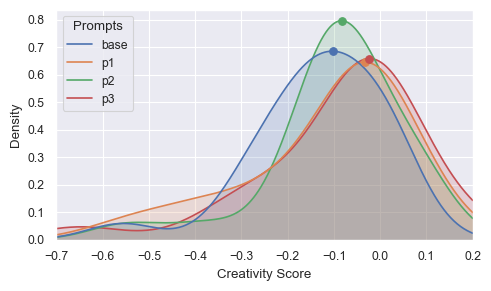

In [17]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def nicer_kde_overlay(
    df,
    x="score_orig",
    hue="Prompts",
    hue_order=("base", "p1", "p2", "p3"),
    title=None,
    xlim=(-0.7, 0.2),
    bw_adjust=1.0,
    gridsize=512,
    fill_alpha=0.18,
    show_peaks=True,
    common_norm=True,     # keep this configurable
):
    sns.set_theme(context="paper", style="darkgrid")
    fig, ax = plt.subplots(figsize=(5, 3))

    # Filled KDEs
    sns.kdeplot(
        data=df, x=x, hue=hue, hue_order=hue_order,
        fill=True, alpha=fill_alpha, linewidth=0,
        multiple="layer",
        common_norm=common_norm,
        common_grid=True,
        bw_adjust=bw_adjust,
        clip=xlim, gridsize=gridsize,
        ax=ax,
    )

    # Outlines
    sns.kdeplot(
        data=df, x=x, hue=hue, hue_order=hue_order,
        fill=False, linewidth=1.2,
        multiple="layer",
        common_norm=common_norm,
        common_grid=True,
        bw_adjust=bw_adjust,
        clip=xlim, gridsize=gridsize,
        ax=ax, legend=True,
    )

    # Peak dots (scaled correctly when common_norm=True)
    if show_peaks:
        xs = np.linspace(xlim[0], xlim[1], gridsize)
        palette = sns.color_palette(n_colors=len(hue_order))

        # total count across included hue levels
        total_n = sum(df.loc[df[hue] == lvl, x].dropna().shape[0] for lvl in hue_order)

        for lvl, color in zip(hue_order, palette):
            vals = df.loc[df[hue] == lvl, x].dropna().to_numpy()
            n = len(vals)
            if n < 2:
                continue

            kde = gaussian_kde(vals)
            kde.set_bandwidth(kde.factor * bw_adjust)
            ys = kde(xs)

            # seaborn common_norm=True scales by group proportion
            if common_norm and total_n > 0:
                ys = ys * (n / total_n)

            i = int(np.argmax(ys))
            ax.scatter(xs[i], ys[i], s=30, color=color, zorder=5)

    ax.set_xlim(*xlim)
    ax.set_xlabel('Creativity Score')
    ax.set_ylabel("Density")

    if title:
        ax.set_title(title)

    plt.tight_layout()
    return fig, ax

# usage:
nicer_kde_overlay(ff, x="score_orig", hue="Prompts", common_norm=True)
plt.savefig("task2_plot/bench2_dist.pdf", bbox_inches="tight") 
# plt.show()


In [18]:
meta = pd.read_csv("dataset/model_meta.csv", sep = ";")
reg = reg.merge(meta[["company", "Model", "name", "model"]], on = ["company", "model"], how = "left")

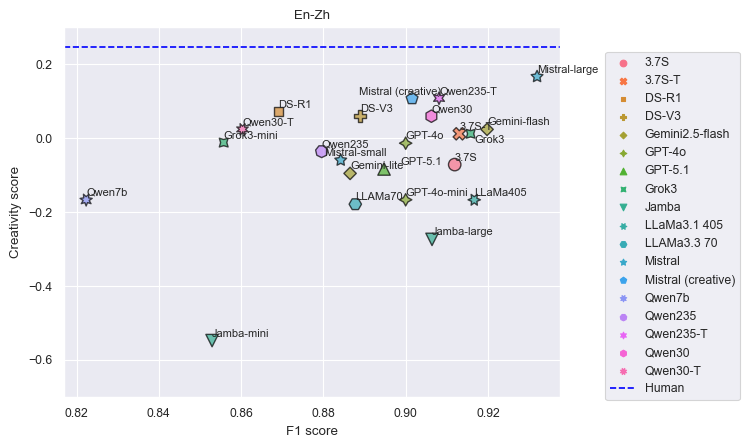

In [19]:
# the max creativity score over 4 prompts
reg["score_orig_avg4p"] = reg.groupby('translation_model')["score_orig"].transform("mean")
reg["score_orig_max"] = reg.groupby('translation_model')["score_orig"].transform("max")
forplot = reg[['f1_score', 'model', 'company', 'name', 'Model', 'size', 'translation_model', "score_orig_avg4p", "score_orig_max"]].drop_duplicates().reset_index()

score = "score_orig_max"#"score_orig_avg4p" #"score"#"score_portion"
sns.set_theme(context="paper", style="darkgrid")
fig, ax1 = plt.subplots()
sns.scatterplot(
    data=forplot,
    x="f1_score",
    y=score,
    hue="Model",
    #size="difficulty",
    #sizes=(50, 200),
    s=80,
    alpha=0.7,
    style="Model",
    edgecolor="black",
    linewidth=1, ax = ax1
)
ax1.set_xlabel("F1 score")
ax1.set_ylabel("Creativity score")
for i, row in forplot.iterrows():
    _y = 0.
    _x = 0.
    if row['name'] == "Mistral-small":
        _y = 0.
        _x = -0.004
    if row['name'] == "Mistral (creative)":
        _y = 0.
        _x = -0.013
    if row['name'] == "GPT-5.1":
        _y = -0.001
        _x = 0.004
    if row['name'] == "Grok3":
        _y = -0.035
        _x = 0.001
    ax1.text(row['f1_score'] + _x, row[score] + _y + 0.011, 
             row['name'], 
             fontsize=8)
ax1.axhline(
    y=0.246, 
    color='blue',
    linestyle='--',
    label='Human'
)
ax1.set_title("En-Zh")
ax1.legend(
    bbox_to_anchor=(1.08, 0.95),
)
ax1.set_ylim([-0.7, 0.3])
plt.savefig("task2_plot/task1_2_auto.pdf", bbox_inches="tight") 

In [20]:
d1["if_max"] = d1["max_v"] == d1["score_orig"]
reg = pd.merge(df8, d1, left_on = "model", right_on = "translation_model", how = "right")

In [21]:
from statistics import mean

reg["score_orig_m"] = reg.groupby(["prompt_mode", "translation_model"], as_index = False).score_orig.transform(mean)
rel = reg[["score_orig_m", "prompt_mode", "translation_model", "f1_score"]].drop_duplicates()

/var/folders/2n/4742tn7s13l5fcnstlm_d7g40000gn/T/ipykernel_71118/2910971573.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  reg["score_orig_m"] = reg.groupby(["prompt_mode", "translation_model"], as_index = False).score_orig.transform(mean)


In [22]:
from scipy.stats import spearmanr 

for mode in reg["prompt_mode"].unique():
    rho, p = spearmanr(rel[rel["prompt_mode"] == mode]["f1_score"], rel[rel["prompt_mode"] == mode]["score_orig_m"])
    print(mode + f" Spearman ρ = {rho:.3f}, p-value = {p:.4f}")

rho, p = spearmanr(rel["f1_score"], rel["score_orig_m"])
print("ALL!" + f" Spearman ρ = {rho:.3f}, p-value = {p:.4f}")


base Spearman ρ = 0.258, p-value = 0.2353
p1 Spearman ρ = 0.265, p-value = 0.2218
p2 Spearman ρ = 0.274, p-value = 0.2051
p3 Spearman ρ = 0.376, p-value = 0.0771
ALL! Spearman ρ = 0.278, p-value = 0.0074
